# MLIP Laboratory Part 2: Validation

In Part 1 you trained two MACE models on silicon DFT data and evaluated energy and force errors.
Fitting energies and forces well is necessary. but not sufficient. A model can overfit to
training configurations while failing on tasks it was never explicitly asked to do.

In this lab you probe three tasks:
1. What are the scaling advantatges that mlips gives you.
2. What accuracies can you expect beyond mae's that you did in lab1. We will consider. For eg: for phonon dispersion - are the second derivatives of the PES (force constants) correct ?
   Phonon frequencies are proportional to the second derivative of energy wrt. positions, so this tests the local curvature of
   the PES, not just the energies.
3. Does the model extrapolate sensibly to isolated atom
   pairs ? How does it react to atoms being too close / too far ?

<div style="border-left: 3px solid #DD8452; padding: 8px 14px; background:#fff7f0">
<b>Note:</b> On Google Colab, set <b>Runtime -> Change runtime type</b> to a GPU. Also make a copy of the notebook before you start running anything.
</div>

## 0. Setup

In [1]:
# Clone course repo and copy pre-trained checkpoints
!git clone https://github.com/Abhivega/6FIFMB6-lab.git
!cp -r 6FIFMB6-lab/checkpoints .
!cp -r 6FIFMB6-lab/SAVED_MODELS .

Cloning into '6FIFMB6-lab'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 59 (delta 0), reused 0 (delta 0), pack-reused 58 (from 1)
Receiving objects: 100% (59/59), 132.24 MiB | 23.70 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [2]:
!pip install -q mace-torch phonopy ase scikit-learn tqdm cuequivariance cuequivariance-torch cuequivariance-ops-torch-cu12

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.8/778.8 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.4/246.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.2/183.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 804.2/804.2 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.6/106.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 23.9 MB/s eta 0

In [3]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ase import Atoms
from ase.build import bulk
from ase.filters import FrechetCellFilter
from ase.io import read, write
from ase.optimize import LBFGS
from mace.calculators import MACECalculator, mace_mp
from tqdm import tqdm

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/usr/local/lib/python3.12/dist-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Device: cuda


# 1. Scaling laws for DFT vs MLIPs

We are going to do a local install of quantum-expresso. The objective of this section is to get a feel for the "speedup" one can expect by using mlips.

In [4]:
%mkdir -p /content/silicon
%cd /content/silicon/
!apt-get -qq install -y quantum-espresso
!wget -q https://pseudopotentials.quantum-espresso.org/upf_files/Si.pbe-n-kjpaw_psl.1.0.0.UPF

/content/silicon
Selecting previously unselected package libfftw3-double3:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package quantum-espresso.
Preparing to unpack .../quantum-espresso_6.7-2build1_amd64.deb ...
Unpacking quantum-espresso (6.7-2build1) ...
Selecting previously unselected package quantum-espresso-data.
Preparing to unpack .../quantum-espresso-data_6.7-2build1_all.deb ...
Unpacking quantum-espresso-data (6.7-2build1) ...
Setting up quantum-espresso-data (6.7-2build1) ...
Setting up libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Setting up quantum-espresso (6.7-2build1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ld

In [5]:

import subprocess, time
from ase.build import bulk
from ase.io import write

si = bulk("Si", "diamond", a=5.43)   # 2-atom primitive cell

pseudopotentials = {"Si": "Si.pbe-n-kjpaw_psl.1.0.0.UPF"}
input_data = {
    "control":   {"calculation": "scf", "prefix": "silicon", "pseudo_dir": "."},
    "system":    {"ecutwfc": 60.0, "ecutrho": 480.0},
    "electrons": {"conv_thr": 1e-6},
}

write("Si.scf.in", si, format="espresso-in",
      input_data=input_data, pseudopotentials=pseudopotentials, kpts=(1, 1, 1))

t0 = time.perf_counter()

subprocess.run("pw.x -in Si.scf.in > Si.scf.out", shell=True, check=True)
dt = time.perf_counter() - t0
print(f"natoms={len(si):4d}  time={dt:7.1f} s")

natoms=   2  time=    7.8 s


**Q**: Do the same thing with varying number of atoms. hint: build

---

supercells. read more [here](https://ase-lib.org/ase/atoms.html#ase.Atoms.repeat)

In [7]:
import subprocess
import time
from ase.build import bulk
from ase.io import write

si_prim = bulk("Si", "diamond", a=5.43)

pseudopotentials = {"Si": "Si.pbe-n-kjpaw_psl.1.0.0.UPF"}

input_data = {
    "control": {
        "calculation": "scf",
        "prefix": "silicon",
        "pseudo_dir": ".",
    },
    "system": {
        "ecutwfc": 60.0,
        "ecutrho": 480.0,
    },
    "electrons": {
        "conv_thr": 1e-6,
    },
}

sizes = [
    (1, 1, 1),  # 2 atoms
    (2, 2, 2),  # 16 atoms
    (3, 3, 3),  # 54 atoms
    (4, 4, 4),  # 128 atoms
]

results = []

for nx, ny, nz in sizes:

    atoms = si_prim.repeat((nx, ny, nz))
    natoms = len(atoms)

    infile = f"Si_{natoms}.in"
    outfile = f"Si_{natoms}.out"

    write(
        infile,
        atoms,
        format="espresso-in",
        input_data=input_data,
        pseudopotentials=pseudopotentials,
        kpts=(1, 1, 1),
    )

    t0 = time.perf_counter()

    subprocess.run(
        f"pw.x -in {infile} > {outfile}",
        shell=True,
        check=True,
    )

    dt = time.perf_counter() - t0

    results.append((natoms, dt))

    print(f"natoms={natoms:4d}   time={dt:8.2f} s")

print("\nSummary")
for natoms, dt in results:
    print(f"{natoms:4d} atoms : {dt:8.2f} s")

natoms=   2   time=    7.07 s
natoms=  16   time=   80.69 s
natoms=  54   time=  821.80 s


CalledProcessError: Command 'pw.x -in Si_128.in > Si_128.out' returned non-zero exit status 137.

In [27]:
import subprocess
import time
from ase.build import bulk
from ase.io import write

si_prim = bulk("Si", "diamond", a=5.43)

pseudopotentials = {"Si": "Si.pbe-n-kjpaw_psl.1.0.0.UPF"}

input_data = {
    "control": {
        "calculation": "scf",
        "prefix": "silicon",
        "pseudo_dir": ".",
    },
    "system": {
        "ecutwfc": 60.0,
        "ecutrho": 480.0,
    },
    "electrons": {
        "conv_thr": 1e-6,
    },
}

sizes = [
    (4, 4, 2),  # 128 atoms
]

results = []

for nx, ny, nz in sizes:

    atoms = si_prim.repeat((nx, ny, nz))
    natoms = len(atoms)

    infile = f"Si_{natoms}.in"
    outfile = f"Si_{natoms}.out"

    write(
        infile,
        atoms,
        format="espresso-in",
        input_data=input_data,
        pseudopotentials=pseudopotentials,
        kpts=(1, 1, 1),
    )

    t0 = time.perf_counter()

    subprocess.run(
        f"pw.x -in {infile} > {outfile}",
        shell=True,
        check=True,
    )

    dt = time.perf_counter() - t0

    results.append((natoms, dt))

    print(f"natoms={natoms:4d}   time={dt:8.2f} s")

print("\nSummary")
for natoms, dt in results:
    print(f"{natoms:4d} atoms : {dt:8.2f} s")

natoms=  64   time= 1018.09 s

Summary
  64 atoms :  1018.09 s


natoms=   2   time=    7.07 s
natoms=  16   time=   80.69 s
natoms=  54   time=  821.80 s

**Q**:Now use a mace model (`calc_mp = mace_mp(model='medium', device=device, default_dtype='float32')`), and calculate the scaling laws for mace. Plot the DFT scaling side by side and
make observations of this.  What can you comment on the scaling behaviour for these two methods as a function of the number of atoms ?? read more [here](https://medium.com/to-journal-to-dev/big-o-notation-and-the-importance-of-function-scalability-352a62c2dfb7)

In [23]:
import time
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk
from mace.calculators import mace_mp

# ==========================================
# Load pretrained MACE model
# ==========================================

device = "cuda"  # use "cpu" if no GPU

calc_mp = mace_mp(
    model="medium",
    device=device,
    default_dtype="float32"
)

# ==========================================
# Generate Si supercells
# ==========================================

si_prim = bulk("Si", "diamond", a=5.43)

supercells = [
    (1, 1, 1),
    (2, 2, 2),
    (3, 3, 3),
    (4,4,4),
    (5,5,5),
    (6,6,6),
    (7,7,7),
    (8,8,8),
    (9,9,9),
    (10,10,10),
]

natoms = []
mace_times = []

# ==========================================
# Time MACE calculations
# ==========================================

for sc in supercells:

    atoms = si_prim.repeat(sc)

    atoms.calc = calc_mp

    start = time.perf_counter()

    energy = atoms.get_potential_energy()

    elapsed = time.perf_counter() - start

    natoms.append(len(atoms))
    mace_times.append(elapsed)

    print(
        f"Atoms = {len(atoms):4d} "
        f"Energy = {energy:12.6f} eV "
        f"Time = {elapsed:.4f} s"
    )

natoms = np.array(natoms)
mace_times = np.array(mace_times)

#DFT timings

dft_times = np.array([
    7,     # 2 atoms
    80,    # 16 atoms
    821,    # 54 atoms
])

# ==========================================
# Fit scaling laws
# ==========================================

p_mace, loga_mace = np.polyfit(
    np.log(natoms),
    np.log(mace_times),
    1
)

# p_dft, loga_dft = np.polyfit(
#     np.log(natoms),
#     np.log(dft_times),
#     1
# )

print("\nScaling exponents")
print("------------------")
# print(f"DFT  : t ~ N^{p_dft:.2f}")
print(f"MACE : t ~ N^{p_mace:.2f}")


Nfit = np.linspace(
    natoms.min(),
    natoms.max(),
    200
)

# fit_dft = np.exp(loga_dft) * Nfit**p_dft
fit_mace = np.exp(loga_mace) * Nfit**p_mace



Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Atoms =    2 Energy =   -10.682180 eV Time = 0.0817 s
Atoms =   16 Energy =   -85.457443 eV Time = 0.1168 s
Atoms =   54 Energy =  -288.418884 eV Time = 0.0698 s
Atoms =  128 Energy =  -683.658020 eV Time = 0.0877 s
Atoms =  250 Energy = -1335.274902 eV Time = 0.1397 s
Atoms =  432 Energy = -2307.359863 eV Time = 0.1857 s
Atoms =  686 Energy = -3663.990234 eV Time = 0.2932 s
Atoms = 1024 Energy = -5469.270020 eV Time = 0.4285 s
Atoms = 1458 Energy = -7787.100098 eV Time = 0.6237 s
Atoms = 2000 Energy = -10681.755859 eV Time = 0.8472 s

Scaling exponents
------------------
MACE : t ~ N^0.33


ValueError: x and y must have same first dimension, but have shapes (10,) and (3,)

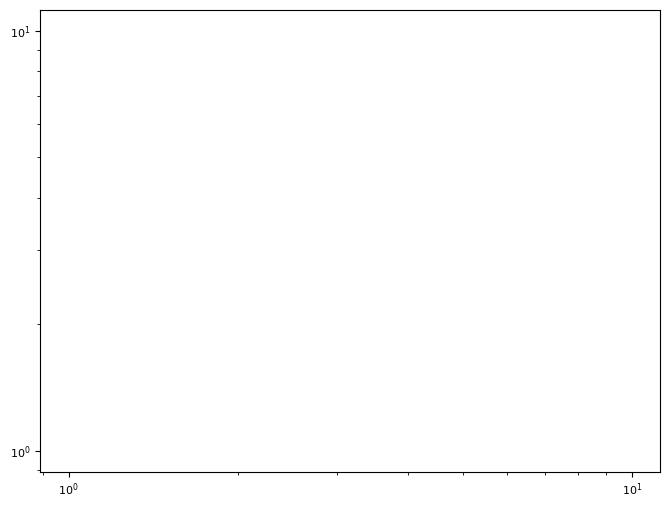

In [24]:
plt.figure(figsize=(8,6))

plt.loglog(
    natoms,
    dft_times,
    "o",
    markersize=8,
    label="DFT timings"
)

plt.loglog(
    natoms,
    mace_times,
    "s",
    markersize=8,
    label="MACE timings"
)

plt.loglog(
    Nfit,
    fit_dft,
    "--",
    label=f"DFT fit (N^{p_dft:.2f})"
)

plt.loglog(
    Nfit,
    fit_mace,
    "--",
    label=f"MACE fit (N^{p_mace:.2f})"
)

plt.xlabel("Number of atoms")
plt.ylabel("Wall time (s)")
plt.title("Scaling of DFT and MACE with system size")
plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.show()

## 2. Phonon Dispersion

A model that reproduces DFT energies and forces on training data may still have wrong
*curvature* of the potential energy surface. Phonon frequencies are proportional to the
square root of the force constants.
Computing the phonon dispersion is therefore a test of whether the
model has learned physically correct interatomic interactions.

We use the **finite-displacement method** (implemented in `phonopy`) (read more [here](https://github.com/materialsproject/public-docs/blob/main/methodology/phonon-dispersion.md)): each atom in a supercell
is displaced by 0.01 A, forces on all neighbours are computed with the MLIP, and the dynamical
matrix is assembled from those force responses. The eigenvalues of the dynamical matrix give
the phonon frequencies.

Feference: Nilsson and Nelin, *Phys. Rev. B* **6**, 3777 (1972) and https://legacy.materialsproject.org/materials/mp-149/

In [ ]:
# Load the two MACE models trained in Lab 1.
# SAVED_MODELS/ is created by running Lab 1. If missing, run Lab 1 first.
calcs = {}
for name in ["Si_alldata", "Si_subset"]:
    p = f"SAVED_MODELS/{name}_stagetwo.model"
    if os.path.exists(p):
        calcs[name] = MACECalculator(
            model_paths=p, device=device, default_dtype="float32"
        )
        print(f"Loaded: {name}")
    else:
        print(f"NOT FOUND: {p}  ← run Lab 1 first to train the models")

if not calcs:
    raise RuntimeError(
        "No trained models found. Complete Lab 1 before running this notebook."
    )

calc_mp = mace_mp(model='medium', device=device, default_dtype='float32')
calcs['mace_pretrained_medium'] = calc_mp

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.optimize import LBFGS
from ase.filters import FrechetCellFilter
from ase.phonons import Phonons
from matplotlib.ticker import FuncFormatter
from ase.units import invcm

EV_TO_CM1 = 1 / invcm
THZ_TO_EV = 4.135667e-3  # eV to 1 THz mode

EXP = {
    "G": [15.53],
    "X": [4.49, 11.35, 12.32, 13.90],
    "L": [3.43, 11.11, 12.60, 14.68],
}


def matched_modes(label, freqs_thz):
    """Pick computed frequencies (sorted, THz) that line up with EXP[label]."""
    f = np.sort(freqs_thz)
    if label == "G":
        return np.array([f[3:6].mean()])                         # optical LTO
    return np.array([f[0:2].mean(), f[2], f[3], f[4:6].mean()])  # TA, LA, LO, TO


fig, axes = plt.subplots(1, len(calcs), figsize=(4.5 * len(calcs), 4.2),
                         sharey=True, squeeze=False)

results = {}

for ax, (name, calc) in zip(axes[0], calcs.items()):
    atoms = bulk("Si", "diamond", a=5.5)
    atoms.calc = calc
    LBFGS(FrechetCellFilter(atoms), logfile=None).run(fmax=0.0001, steps=3000)

    # Relaxed cubic lattice constant: primitive volume = a**3 / 4.
    a_relaxed = (4 * atoms.get_volume()) ** (1 / 3)

    ph = Phonons(atoms, calc, supercell=(6, 6, 6), delta=0.01, name=f"ph_{name}")
    ph.run()
    ph.read(acoustic=True)
    ph.clean()

    path = atoms.cell.bandpath("GXULGK", npoints=100)

    # Error vs experiment: frequencies (eV -> THz) at the tested points.
    abs_errors = []
    for label in EXP:
        omega = ph.band_structure([path.special_points[label]], verbose=False)[0]
        calc_thz = matched_modes(label, omega / THZ_TO_EV)
        abs_errors.extend(np.abs(calc_thz - np.array(EXP[label])))
    mae = float(np.mean(abs_errors))
    results[name] = {"a": a_relaxed, "mae": mae}

    #ph.get_band_structure(path).plot(ax=ax, emin=-0.01, emax=0.07)
    ph.get_band_structure(path).plot(
    ax=ax,
    emin=0 / EV_TO_CM1,
    emax=600 / EV_TO_CM1
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{y * EV_TO_CM1:.0f}")
    )

    _, xpos, labels = path.get_linear_kpoint_axis()
    for x, label in zip(xpos, labels):
        for nu in EXP.get(label, []):
            ax.plot(x, nu * THZ_TO_EV, "o", c="crimson", mec="k", ms=6, zorder=5)

    ax.set_title(f"{name}\n$a$ = {a_relaxed:.3f} Å,  MAE = {mae:.2f} THz")

axes[0, 0].set_ylabel(r"Frequency (cm -1)")
plt.tight_layout()
plt.show()


**Q** Run the same calculations with a smaller supercell, something like 3X3X3. Plot it and make a note of what you see.

## 3. Dimer Potential Energy Curves

Universal MLIPs such as MACE-MP are trained on millions of DFT calculations spanning much
of the periodic table. However, the training set is almost entirely *periodic bulk and slab*
configurations isolated two-atom dimers are quiet rare to be part of the traing data.

A dimer scan is therefore a test of extrapolation. does the model produce a physically
reasonable pair potential in a regime it has never encountered (both when atoms are really close as well as really far) ?

A physically correct pair potential should:
- Have a minimum close to the experimental bond length
- Repulsive at short distance
- Decay smoothly to some constant as r approaches infinity

We compare two MACE-MP foundation models:
- **MACE-MP medium** (2023) : trained on the Materials Project database
- **MACE-MP MPA-0** (2024) : trained on a much larger and more diverse dataset

In [ ]:
mace_medium = mace_mp(model="medium", device=device, default_dtype="float32")
mace_mpa = mace_mp(model="medium-mpa-0", device=device, default_dtype="float32")

scan_models = {
    "MACE-MP medium": mace_medium,
    "MACE-MP MPA-0": mace_mpa,
}

In [ ]:
def dimer_scan(elem1, elem2, calc, r_min=0.4, r_max=15.0, n=200):
    distances = np.linspace(r_min, r_max, n)
    energies = []
    for r in distances:
        a = Atoms(
            [elem1, elem2],
            positions=[[0, 0, 0], [r, 0, 0]],
            cell=[20, 20, 20],
            pbc=False,
        )
        a.calc = calc
        energies.append(a.get_potential_energy())
    E = np.array(energies)
    return distances, E

In [ ]:
pairs = [("N", "N"), ("Si", "Si"), ("C", "Ti"), ("O", "H")]
pair_data = {}
for e1, e2 in pairs:
    pair_data[(e1, e2)] = {}
    print(f"Scanning {e1}-{e2} ...", end=" ")
    for mname, c in scan_models.items():
        pair_data[(e1, e2)][mname] = dimer_scan(e1, e2, c)
    print("done")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (e1, e2) in zip(axes, pairs):
    for mname, (r, E) in pair_data[(e1, e2)].items():
        ax.plot(r, E, label=mname)
    ax.axhline(0, color="k", lw=0.5, ls=":")
    ax.set_xlabel("Distance (A)")
    ax.set_ylabel("E (eV)")
    ax.set_title(f"{e1}–{e2}")
    ax.set_ylim(-20, 5)
    ax.set_xlim(0.4, 5)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Q.** For some systems, you are observing anomalies as the distance between two atoms get really close. Attempt to explain what might have caused this ??

**Q** For each pair, identify the predicted equilibrium bond length (the distance at the
energy minimum) for both models. Fill in the table and report the error relative to experiment.

| Pair   | Experimental (A) | MACE-MP medium | MACE-MP MPA-0|
|--------|---------------|----------------------|---------------------|
| N–N    | 1.10          |      fill this..          |                     |
| Si–Si  | 2.35          |                      |                     |
| O–H    | 0.96          |                      |                     |

**Q** Plot the same using the potentials we trained (use the calc dictionary from above) as well as the pretrained models for the Si-Si dimer. Make a plot out of them. State what you observe. hint: look at the values first before you set the x and y limit if you are reusing the previous plot).

**Q** For the plot above, explain what the energy approaches to as distance grows to infinity. What is the significance of this number ?? Can you identify where this number came from ? (hint: look at the training code for the model in Lab1)